# Renewal Probability Prediction - Model Training

## Purpose
This notebook trains multiple machine learning models to predict the likelihood that a customer will renew their contract:
- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier
- Gradient Boosting Classifier
- Support Vector Machine (SVM)
- **Ensemble Models:**
  - Voting Classifier (Soft Voting)
  - Stacking Classifier

## Workflow
1. Data Loading & Feature Engineering
2. Hyperparameter Tuning (Optional)
3. Model Training
4. Cross-Validation
5. Ensemble Models
6. Model Evaluation & Comparison
7. Overfitting Analysis
8. Save All Models

**All trained models are automatically saved to the `models/` directory.**

In [1]:
# Install required packages
!uv add scikit-learn xgboost matplotlib seaborn pandas numpy openpyxl joblib

Resolved 54 packages in 2ms
Audited 47 packages in 7ms


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
from datetime import datetime
import os

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import xgboost as xgb

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Data and Create Target Variable

In [3]:
# Try to load processed data first, otherwise load from Excel
processed_data_path = Path("renewal_data_processed.csv")
excel_paths = [
    Path("../../customer_data_25000.xlsx"),
    Path("../customer_data_25000.xlsx"),
    Path("customer_data_25000.xlsx"),
    Path("D:/Internship/Renewal-Upsell-Advisor/Research/customer_data_25000.xlsx")
]

if processed_data_path.exists():
    print("Loading processed data from renewal_data_processed.csv...")
    df = pd.read_csv(processed_data_path)
    print(f"✓ Loaded processed data: {df.shape[0]:,} rows × {df.shape[1]} columns")
else:
    print("Processed data not found. Loading from Excel and performing feature engineering...")
    data_path = None
    for path in excel_paths:
        if path.exists():
            data_path = path
            break
    
    if data_path is None:
        raise FileNotFoundError("Could not find customer_data_25000.xlsx. Please check the file path.")
    
    df = pd.read_excel(data_path, sheet_name="Accounts")
    
    # Replicate feature engineering from EDA
    from datetime import datetime, timedelta
    
    # Convert date columns to datetime
    date_columns = ['contract_start_date', 'contract_end_date', 'renewal_date', 'last_contact_date']
    for col in date_columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Calculate days until renewal
    if 'renewal_date' in df.columns:
        today = pd.Timestamp.now()
        df['days_until_renewal'] = (df['renewal_date'] - today).dt.days
    
    # Calculate contract duration in months
    if 'contract_start_date' in df.columns and 'contract_end_date' in df.columns:
        df['contract_duration_months'] = (
            (df['contract_end_date'] - df['contract_start_date']).dt.days / 30.44
        ).round(1)
    
    # Calculate days since last contact
    if 'last_contact_date' in df.columns:
        today = pd.Timestamp.now()
        df['days_since_last_contact'] = (today - df['last_contact_date']).dt.days
    
    # Create renewal target variable
    if 'status' in df.columns:
        renewal_keywords = ['active', 'renewed', 'renewal', 'renew']
        df['will_renew'] = df['status'].str.lower().str.contains('|'.join(renewal_keywords), na=False).astype(int)
    
    print(f"✓ Loaded and processed data: {df.shape[0]:,} rows × {df.shape[1]} columns")

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Loading processed data from renewal_data_processed.csv...
✓ Loaded processed data: 24,874 rows × 33 columns

Dataset shape: (24874, 33)
Columns: ['name', 'domain', 'industry', 'company_size', 'arr', 'mrr', 'contract_start_date', 'contract_end_date', 'renewal_date', 'last_contact_date', 'status', 'renewal_stage', 'health_score', 'risk_score', 'relationship_score', 'churn_probability', 'sentiment_score', 'sentiment_category', 'licenses_total', 'licenses_used', 'utilization_percentage', 'csm_name', 'csm_email', 'primary_contact_name', 'primary_contact_email', 'primary_contact_phone', 'salesforce_id', 'days_until_renewal', 'contract_duration_months', 'renewal_stage_calculated', 'days_since_last_contact', 'will_renew', 'health_score_bin']


In [4]:
# Check target variable
if 'will_renew' in df.columns:
    print("Target Variable (will_renew) Distribution:")
    print(df['will_renew'].value_counts())
    print(f"\nRenewal Rate: {df['will_renew'].mean():.2%}")
    print(f"Non-Renewal Rate: {(1 - df['will_renew'].mean()):.2%}")
else:
    raise ValueError("Target variable 'will_renew' not found in dataset!")

Target Variable (will_renew) Distribution:
will_renew
1    20086
0     4788
Name: count, dtype: int64

Renewal Rate: 80.75%
Non-Renewal Rate: 19.25%


## 2. Feature Selection and Preprocessing

In [5]:
# Select features for modeling
# Numerical features for renewal prediction
numerical_features = [
    'health_score', 'risk_score', 'relationship_score', 'sentiment_score',
    'churn_probability', 'utilization_percentage', 'arr', 'mrr',
    'contract_duration_months', 'days_until_renewal', 'days_since_last_contact'
]

# Categorical features
categorical_features = ['industry', 'company_size']

# Check which features exist in the dataset
available_numerical = [f for f in numerical_features if f in df.columns]
available_categorical = [f for f in categorical_features if f in df.columns]

print("Available Numerical Features:")
print(available_numerical)
print(f"\nAvailable Categorical Features:")
print(available_categorical)

# Create feature dataframe
feature_df = df[available_numerical + available_categorical + ['will_renew']].copy()

# Handle missing values
print(f"\nMissing values before imputation:")
missing = feature_df.isnull().sum()
print(missing[missing > 0])

# Fill missing values in numerical columns with median
for col in available_numerical:
    if feature_df[col].isnull().sum() > 0:
        feature_df[col].fillna(feature_df[col].median(), inplace=True)

# Fill missing values in categorical columns with mode
for col in available_categorical:
    if feature_df[col].isnull().sum() > 0:
        feature_df[col].fillna(feature_df[col].mode()[0], inplace=True)

print(f"\nMissing values after imputation: {feature_df.isnull().sum().sum()}")

# Encode categorical features
label_encoders = {}
for col in available_categorical:
    le = LabelEncoder()
    feature_df[col] = le.fit_transform(feature_df[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

# Prepare X and y
X = feature_df[available_numerical + available_categorical]
y = feature_df['will_renew']

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Features: {list(X.columns)}")

Available Numerical Features:
['health_score', 'risk_score', 'relationship_score', 'sentiment_score', 'churn_probability', 'utilization_percentage', 'arr', 'mrr', 'contract_duration_months', 'days_until_renewal', 'days_since_last_contact']

Available Categorical Features:
['industry', 'company_size']

Missing values before imputation:
Series([], dtype: int64)

Missing values after imputation: 0
Encoded industry: 16 unique values
Encoded company_size: 4 unique values

Final feature matrix shape: (24874, 13)
Target variable shape: (24874,)
Features: ['health_score', 'risk_score', 'relationship_score', 'sentiment_score', 'churn_probability', 'utilization_percentage', 'arr', 'mrr', 'contract_duration_months', 'days_until_renewal', 'days_since_last_contact', 'industry', 'company_size']


## 3. Data Splitting and Scaling

In [6]:
# Split data into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"\nTraining set renewal rate: {y_train.mean():.2%}")
print(f"Test set renewal rate: {y_test.mean():.2%}")

# Scale features (for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\n✓ Data split and scaled successfully!")

Training set: 19,899 samples
Test set: 4,975 samples

Training set renewal rate: 80.75%
Test set renewal rate: 80.74%

✓ Data split and scaled successfully!


## 4. Hyperparameter Tuning

In [7]:
# Import hyperparameter tuning tools
from scipy.stats import randint, uniform

# Set to True to enable hyperparameter tuning, False to use default parameters
ENABLE_TUNING = True  # Change to False to skip tuning and use default parameters

# Define parameter grids for each model
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'min_samples_split': [2, 5, 10]
    },
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'lbfgs']
    }
}

tuned_models = {}

if ENABLE_TUNING:
    print("=" * 80)
    print("HYPERPARAMETER TUNING")
    print("=" * 80)
    print("This may take several minutes...\n")
    
    # Tune Random Forest
    print("Tuning Random Forest...")
    rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf_search = RandomizedSearchCV(
        rf_base, param_grids['Random Forest'],
        n_iter=20, cv=3, scoring='roc_auc',
        n_jobs=-1, random_state=42, verbose=1
    )
    rf_search.fit(X_train, y_train)
    tuned_models['Random Forest'] = rf_search.best_estimator_
    print(f"  Best Score: {rf_search.best_score_:.4f}")
    print(f"  Best Params: {rf_search.best_params_}\n")
    
    # Tune XGBoost
    print("Tuning XGBoost...")
    xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    xgb_search = RandomizedSearchCV(
        xgb_base, param_grids['XGBoost'],
        n_iter=20, cv=3, scoring='roc_auc',
        n_jobs=-1, random_state=42, verbose=1
    )
    xgb_search.fit(X_train, y_train)
    tuned_models['XGBoost'] = xgb_search.best_estimator_
    print(f"  Best Score: {xgb_search.best_score_:.4f}")
    print(f"  Best Params: {xgb_search.best_params_}\n")
    
    # Tune Gradient Boosting
    print("Tuning Gradient Boosting...")
    gb_base = GradientBoostingClassifier(random_state=42)
    gb_search = RandomizedSearchCV(
        gb_base, param_grids['Gradient Boosting'],
        n_iter=20, cv=3, scoring='roc_auc',
        n_jobs=-1, random_state=42, verbose=1
    )
    gb_search.fit(X_train, y_train)
    tuned_models['Gradient Boosting'] = gb_search.best_estimator_
    print(f"  Best Score: {gb_search.best_score_:.4f}")
    print(f"  Best Params: {gb_search.best_params_}\n")
    
    # Tune Logistic Regression
    print("Tuning Logistic Regression...")
    lr_base = LogisticRegression(random_state=42, max_iter=1000)
    lr_search = RandomizedSearchCV(
        lr_base, param_grids['Logistic Regression'],
        n_iter=15, cv=3, scoring='roc_auc',
        n_jobs=-1, random_state=42, verbose=1
    )
    lr_search.fit(X_train_scaled, y_train)
    tuned_models['Logistic Regression'] = lr_search.best_estimator_
    print(f"  Best Score: {lr_search.best_score_:.4f}")
    print(f"  Best Params: {lr_search.best_params_}\n")
    
    print("=" * 80)
    print("Hyperparameter tuning completed! ✓")
    print("=" * 80)
else:
    print("Hyperparameter tuning is disabled. Using default parameters.")
    print("Set ENABLE_TUNING = True to enable tuning.")

HYPERPARAMETER TUNING
This may take several minutes...

Tuning Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score: 1.0000
  Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}

Tuning XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score: 1.0000
  Best Params: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 0.8}

Tuning Gradient Boosting...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score: 1.0000
  Best Params: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 3, 'learning_rate': 0.01}

Tuning Logistic Regression...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  Best Score: 0.9934
  Best Params: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.01}

Hyperparameter tuning completed! ✓


In [8]:
# Initialize models - use tuned models if available, otherwise use defaults
models = {}

if ENABLE_TUNING and len(tuned_models) > 0:
    models['Logistic Regression'] = tuned_models.get('Logistic Regression', 
        LogisticRegression(random_state=42, max_iter=1000))
    models['Random Forest'] = tuned_models.get('Random Forest',
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    models['XGBoost'] = tuned_models.get('XGBoost',
        xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
    models['Gradient Boosting'] = tuned_models.get('Gradient Boosting',
        GradientBoostingClassifier(random_state=42))
    print("Using tuned hyperparameters for models where available.")
else:
    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    }
    print("Using default hyperparameters.")

# Add SVM (not tuned due to computational cost)
models['SVM'] = SVC(probability=True, random_state=42)

# Store results
results = {}
predictions = {}
probabilities = {}

print("\nTraining models...")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Use scaled features for Logistic Regression and SVM
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    
    predictions[name] = y_pred
    probabilities[name] = y_proba
    
    # Calculate training performance for overfitting check
    if name in ['Logistic Regression', 'SVM']:
        y_train_pred = model.predict(X_train_scaled)
        y_train_proba = model.predict_proba(X_train_scaled)[:, 1]
    else:
        y_train_pred = model.predict(X_train)
        y_train_proba = model.predict_proba(X_train)[:, 1]
    
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    
    # Store training metrics
    results[name]['Train Accuracy'] = train_accuracy
    results[name]['Train F1'] = train_f1
    results[name]['Train ROC-AUC'] = train_roc_auc
    
    # Calculate overfitting gap
    results[name]['Accuracy Gap'] = train_accuracy - accuracy
    results[name]['F1 Gap'] = train_f1 - f1
    results[name]['ROC-AUC Gap'] = train_roc_auc - roc_auc
    
    print(f"  Test Accuracy: {accuracy:.4f} | Train Accuracy: {train_accuracy:.4f} | Gap: {train_accuracy - accuracy:.4f}")
    print(f"  Test F1-Score: {f1:.4f} | Train F1-Score: {train_f1:.4f} | Gap: {train_f1 - f1:.4f}")
    print(f"  Test ROC-AUC: {roc_auc:.4f} | Train ROC-AUC: {train_roc_auc:.4f} | Gap: {train_roc_auc - roc_auc:.4f}")

print("\n" + "=" * 80)
print("All models trained successfully!")

Using tuned hyperparameters for models where available.

Training models...

Training Logistic Regression...
  Test Accuracy: 0.9644 | Train Accuracy: 0.9621 | Gap: -0.0023
  Test F1-Score: 0.9779 | Train F1-Score: 0.9764 | Gap: -0.0015
  Test ROC-AUC: 0.9942 | Train ROC-AUC: 0.9934 | Gap: -0.0008

Training Random Forest...
  Test Accuracy: 0.9998 | Train Accuracy: 1.0000 | Gap: 0.0002
  Test F1-Score: 0.9999 | Train F1-Score: 1.0000 | Gap: 0.0001
  Test ROC-AUC: 1.0000 | Train ROC-AUC: 1.0000 | Gap: 0.0000

Training XGBoost...
  Test Accuracy: 0.9994 | Train Accuracy: 1.0000 | Gap: 0.0006
  Test F1-Score: 0.9996 | Train F1-Score: 1.0000 | Gap: 0.0004
  Test ROC-AUC: 1.0000 | Train ROC-AUC: 1.0000 | Gap: 0.0000

Training Gradient Boosting...
  Test Accuracy: 0.9998 | Train Accuracy: 1.0000 | Gap: 0.0002
  Test F1-Score: 0.9999 | Train F1-Score: 1.0000 | Gap: 0.0001
  Test ROC-AUC: 1.0000 | Train ROC-AUC: 1.0000 | Gap: 0.0000

Training SVM...
  Test Accuracy: 0.9827 | Train Accuracy: 0.

In [9]:
# Perform cross-validation for more robust evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Performing 5-Fold Cross-Validation...")
print("=" * 80)

for name, model in models.items():
    print(f"\n{name}...")
    
    # Use scaled features for Logistic Regression and SVM
    if name in ['Logistic Regression', 'SVM']:
        X_cv = X_train_scaled.values
    else:
        X_cv = X_train.values
    
    # Cross-validation scores
    cv_accuracy = cross_val_score(model, X_cv, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_f1 = cross_val_score(model, X_cv, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_roc_auc = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    cv_results[name] = {
        'CV Accuracy Mean': cv_accuracy.mean(),
        'CV Accuracy Std': cv_accuracy.std(),
        'CV F1 Mean': cv_f1.mean(),
        'CV F1 Std': cv_f1.std(),
        'CV ROC-AUC Mean': cv_roc_auc.mean(),
        'CV ROC-AUC Std': cv_roc_auc.std()
    }
    
    print(f"  CV Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std() * 2:.4f})")
    print(f"  CV F1-Score: {cv_f1.mean():.4f} (+/- {cv_f1.std() * 2:.4f})")
    print(f"  CV ROC-AUC: {cv_roc_auc.mean():.4f} (+/- {cv_roc_auc.std() * 2:.4f})")

# Create CV results DataFrame
cv_results_df = pd.DataFrame(cv_results).T
print("\n" + "=" * 80)
print("Cross-Validation Results Summary:")
print(cv_results_df.round(4))

Performing 5-Fold Cross-Validation...

Logistic Regression...
  CV Accuracy: 0.9622 (+/- 0.0078)
  CV F1-Score: 0.9765 (+/- 0.0050)
  CV ROC-AUC: 0.9934 (+/- 0.0016)

Random Forest...
  CV Accuracy: 0.9999 (+/- 0.0002)
  CV F1-Score: 1.0000 (+/- 0.0001)
  CV ROC-AUC: 1.0000 (+/- 0.0000)

XGBoost...
  CV Accuracy: 0.9990 (+/- 0.0013)
  CV F1-Score: 0.9994 (+/- 0.0008)
  CV ROC-AUC: 1.0000 (+/- 0.0000)

Gradient Boosting...
  CV Accuracy: 0.9999 (+/- 0.0002)
  CV F1-Score: 1.0000 (+/- 0.0001)
  CV ROC-AUC: 1.0000 (+/- 0.0000)

SVM...
  CV Accuracy: 0.9789 (+/- 0.0063)
  CV F1-Score: 0.9869 (+/- 0.0039)
  CV ROC-AUC: 0.9978 (+/- 0.0007)

Cross-Validation Results Summary:
                     CV Accuracy Mean  CV Accuracy Std  CV F1 Mean  CV F1 Std  \
Logistic Regression            0.9622           0.0039      0.9765     0.0025   
Random Forest                  0.9999           0.0001      1.0000     0.0001   
XGBoost                        0.9990           0.0007      0.9994     0.0004   

## 7. Overfitting Analysis

OVERFITTING ANALYSIS

Training vs Test Performance Comparison:
                 Model  Train Accuracy  Test Accuracy  Accuracy Gap  Train F1  \
0  Logistic Regression          0.9621         0.9644       -0.0023    0.9764   
1        Random Forest          1.0000         0.9998        0.0002    1.0000   
2              XGBoost          1.0000         0.9994        0.0006    1.0000   
3    Gradient Boosting          1.0000         0.9998        0.0002    1.0000   
4                  SVM          0.9844         0.9827        0.0017    0.9903   

   Test F1  F1 Gap  Train ROC-AUC  Test ROC-AUC  ROC-AUC Gap  
0   0.9779 -0.0015         0.9934        0.9942      -0.0008  
1   0.9999  0.0001         1.0000        1.0000       0.0000  
2   0.9996  0.0004         1.0000        1.0000       0.0000  
3   0.9999  0.0001         1.0000        1.0000       0.0000  
4   0.9893  0.0010         0.9986        0.9987      -0.0000  


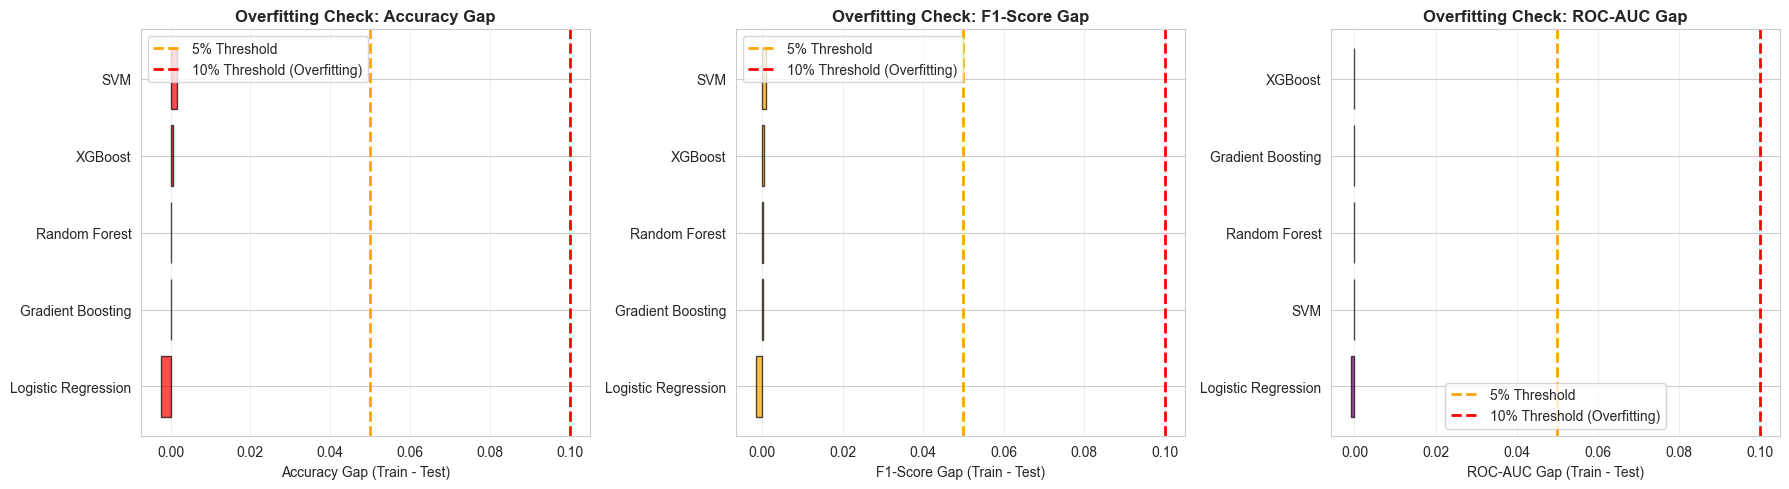


OVERFITTING ASSESSMENT

✓ Logistic Regression - No significant overfitting detected
   Test Accuracy: 0.9644
   Accuracy Gap: -0.0023

⚠️  Random Forest - POTENTIALLY OVERFITTED
   Test Accuracy: 0.9998
   Accuracy Gap: 0.0002
   F1 Gap: 0.0001
   ROC-AUC Gap: 0.0000
   Reasons: Perfect/near-perfect test score (≥99.9%)

⚠️  XGBoost - POTENTIALLY OVERFITTED
   Test Accuracy: 0.9994
   Accuracy Gap: 0.0006
   F1 Gap: 0.0004
   ROC-AUC Gap: 0.0000
   Reasons: Perfect/near-perfect test score (≥99.9%)

⚠️  Gradient Boosting - POTENTIALLY OVERFITTED
   Test Accuracy: 0.9998
   Accuracy Gap: 0.0002
   F1 Gap: 0.0001
   ROC-AUC Gap: 0.0000
   Reasons: Perfect/near-perfect test score (≥99.9%)

✓ SVM - No significant overfitting detected
   Test Accuracy: 0.9827
   Accuracy Gap: 0.0017

🚨 WARNING: 3 model(s) show signs of overfitting!
   Overfitted models: Random Forest, XGBoost, Gradient Boosting

💡 Recommendations:
   - Increase regularization (reduce model complexity)
   - Add more training 

In [10]:
# Analyze overfitting by comparing training vs test performance
print("=" * 80)
print("OVERFITTING ANALYSIS")
print("=" * 80)

overfitting_analysis = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Accuracy': [results[m].get('Train Accuracy', 0) for m in results.keys()],
    'Test Accuracy': [results[m]['Accuracy'] for m in results.keys()],
    'Accuracy Gap': [results[m].get('Accuracy Gap', 0) for m in results.keys()],
    'Train F1': [results[m].get('Train F1', 0) for m in results.keys()],
    'Test F1': [results[m]['F1-Score'] for m in results.keys()],
    'F1 Gap': [results[m].get('F1 Gap', 0) for m in results.keys()],
    'Train ROC-AUC': [results[m].get('Train ROC-AUC', 0) for m in results.keys()],
    'Test ROC-AUC': [results[m]['ROC-AUC'] for m in results.keys()],
    'ROC-AUC Gap': [results[m].get('ROC-AUC Gap', 0) for m in results.keys()]
})

print("\nTraining vs Test Performance Comparison:")
print(overfitting_analysis.round(4))

# Visualize overfitting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy gap
overfitting_analysis_sorted = overfitting_analysis.sort_values('Accuracy Gap', ascending=False)
axes[0].barh(range(len(overfitting_analysis_sorted)), overfitting_analysis_sorted['Accuracy Gap'].values,
             color='red', alpha=0.7, edgecolor='black')
axes[0].axvline(0.05, color='orange', linestyle='--', linewidth=2, label='5% Threshold')
axes[0].axvline(0.10, color='red', linestyle='--', linewidth=2, label='10% Threshold (Overfitting)')
axes[0].set_yticks(range(len(overfitting_analysis_sorted)))
axes[0].set_yticklabels(overfitting_analysis_sorted['Model'])
axes[0].set_xlabel('Accuracy Gap (Train - Test)', fontsize=10)
axes[0].set_title('Overfitting Check: Accuracy Gap', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

# F1 gap
overfitting_analysis_sorted_f1 = overfitting_analysis.sort_values('F1 Gap', ascending=False)
axes[1].barh(range(len(overfitting_analysis_sorted_f1)), overfitting_analysis_sorted_f1['F1 Gap'].values,
             color='orange', alpha=0.7, edgecolor='black')
axes[1].axvline(0.05, color='orange', linestyle='--', linewidth=2, label='5% Threshold')
axes[1].axvline(0.10, color='red', linestyle='--', linewidth=2, label='10% Threshold (Overfitting)')
axes[1].set_yticks(range(len(overfitting_analysis_sorted_f1)))
axes[1].set_yticklabels(overfitting_analysis_sorted_f1['Model'])
axes[1].set_xlabel('F1-Score Gap (Train - Test)', fontsize=10)
axes[1].set_title('Overfitting Check: F1-Score Gap', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

# ROC-AUC gap
overfitting_analysis_sorted_roc = overfitting_analysis.sort_values('ROC-AUC Gap', ascending=False)
axes[2].barh(range(len(overfitting_analysis_sorted_roc)), overfitting_analysis_sorted_roc['ROC-AUC Gap'].values,
             color='purple', alpha=0.7, edgecolor='black')
axes[2].axvline(0.05, color='orange', linestyle='--', linewidth=2, label='5% Threshold')
axes[2].axvline(0.10, color='red', linestyle='--', linewidth=2, label='10% Threshold (Overfitting)')
axes[2].set_yticks(range(len(overfitting_analysis_sorted_roc)))
axes[2].set_yticklabels(overfitting_analysis_sorted_roc['Model'])
axes[2].set_xlabel('ROC-AUC Gap (Train - Test)', fontsize=10)
axes[2].set_title('Overfitting Check: ROC-AUC Gap', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='x')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# Identify overfitted models
print("\n" + "=" * 80)
print("OVERFITTING ASSESSMENT")
print("=" * 80)

overfitted_models = []
for idx, row in overfitting_analysis.iterrows():
    model_name = row['Model']
    accuracy_gap = row['Accuracy Gap']
    f1_gap = row['F1 Gap']
    roc_gap = row['ROC-AUC Gap']
    test_acc = row['Test Accuracy']
    
    # Check for overfitting indicators
    is_overfitted = False
    reasons = []
    
    if test_acc >= 0.999:  # Perfect or near-perfect test score
        is_overfitted = True
        reasons.append("Perfect/near-perfect test score (≥99.9%)")
    
    if accuracy_gap > 0.10:  # More than 10% gap
        is_overfitted = True
        reasons.append(f"Large accuracy gap ({accuracy_gap:.2%})")
    
    if f1_gap > 0.10:
        is_overfitted = True
        reasons.append(f"Large F1 gap ({f1_gap:.2%})")
    
    if roc_gap > 0.10:
        is_overfitted = True
        reasons.append(f"Large ROC-AUC gap ({roc_gap:.2%})")
    
    if is_overfitted:
        overfitted_models.append(model_name)
        print(f"\n⚠️  {model_name} - POTENTIALLY OVERFITTED")
        print(f"   Test Accuracy: {test_acc:.4f}")
        print(f"   Accuracy Gap: {accuracy_gap:.4f}")
        print(f"   F1 Gap: {f1_gap:.4f}")
        print(f"   ROC-AUC Gap: {roc_gap:.4f}")
        print(f"   Reasons: {', '.join(reasons)}")
    else:
        print(f"\n✓ {model_name} - No significant overfitting detected")
        print(f"   Test Accuracy: {test_acc:.4f}")
        print(f"   Accuracy Gap: {accuracy_gap:.4f}")

if len(overfitted_models) > 0:
    print(f"\n🚨 WARNING: {len(overfitted_models)} model(s) show signs of overfitting!")
    print(f"   Overfitted models: {', '.join(overfitted_models)}")
    print(f"\n💡 Recommendations:")
    print(f"   - Increase regularization (reduce model complexity)")
    print(f"   - Add more training data if possible")
    print(f"   - Use simpler models or reduce hyperparameters")
    print(f"   - Consider using Logistic Regression or SVM (less prone to overfitting)")
else:
    print(f"\n✅ No significant overfitting detected in any model!")

## 8. Model Performance 

Model Performance Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest          0.9998     0.9998  1.0000    0.9999   1.0000
Gradient Boosting      0.9998     0.9998  1.0000    0.9999   1.0000
XGBoost                0.9994     0.9995  0.9998    0.9996   1.0000
SVM                    0.9827     0.9910  0.9876    0.9893   0.9987
Logistic Regression    0.9644     0.9812  0.9746    0.9779   0.9942


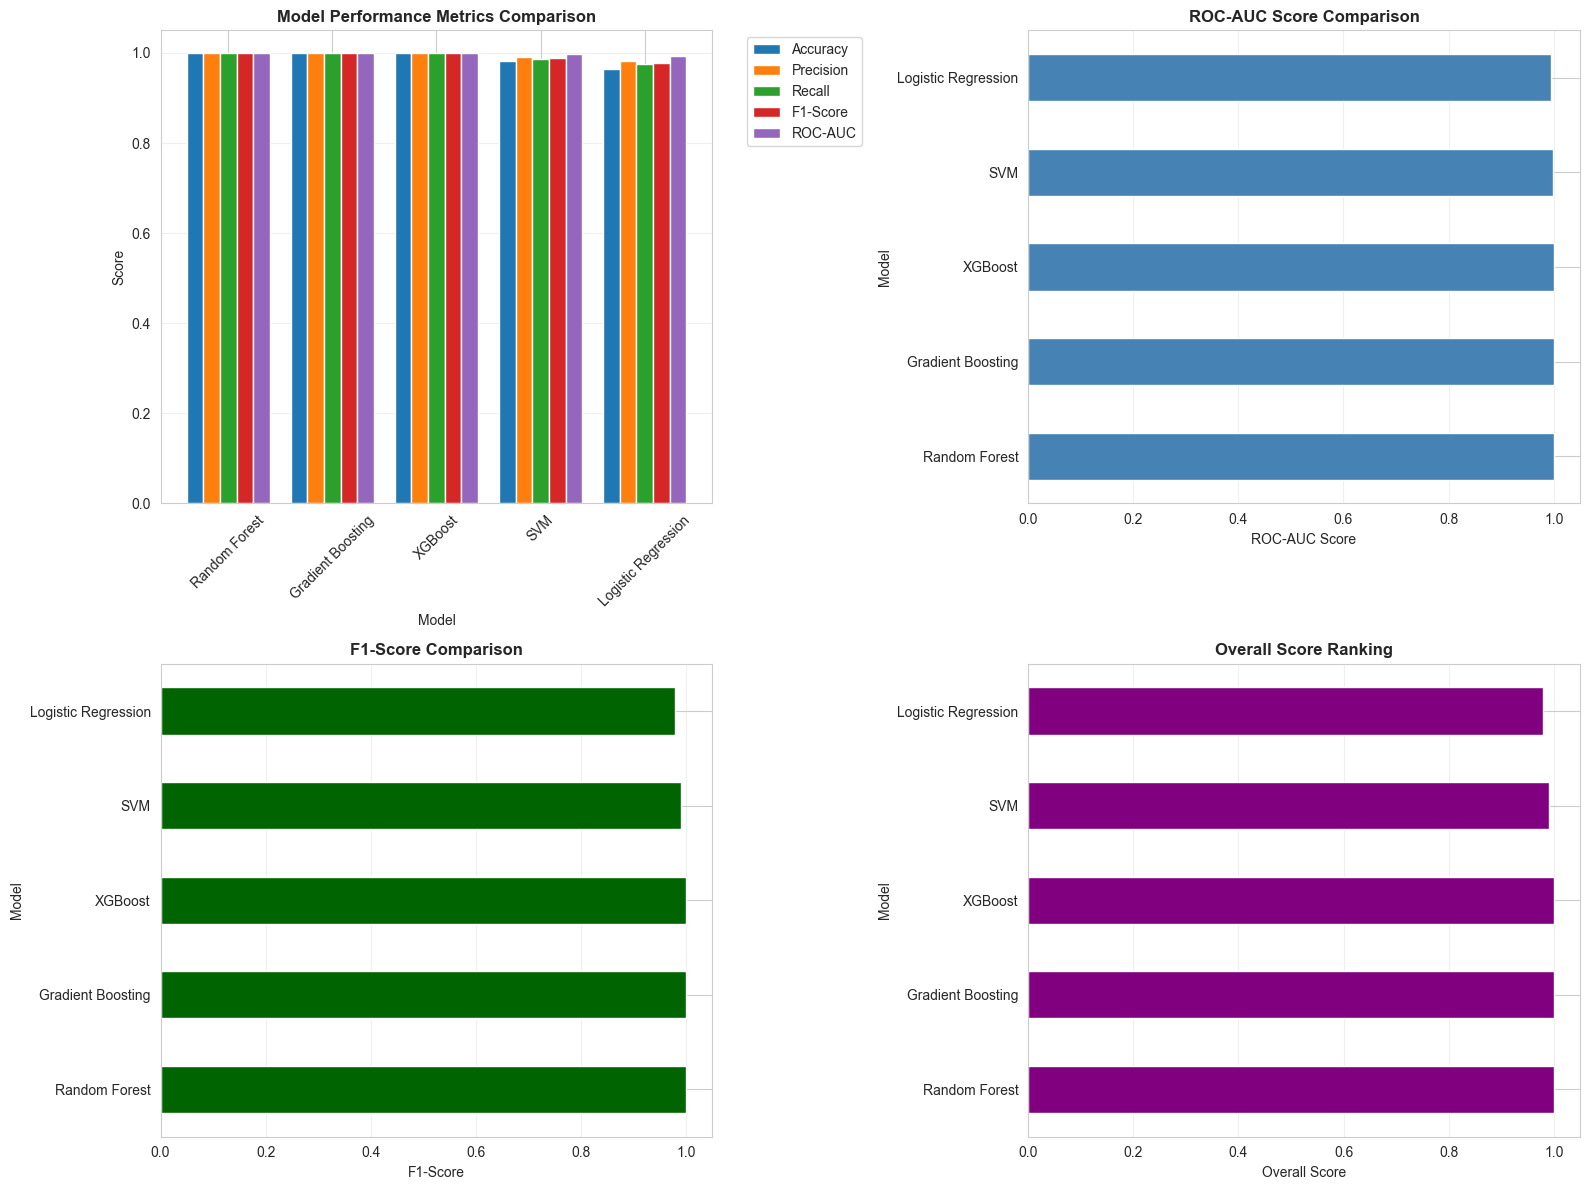


Overall Score Ranking:
                     Overall Score
Random Forest               0.9999
Gradient Boosting           0.9999
XGBoost                     0.9997
SVM                         0.9902
Logistic Regression         0.9788


In [12]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).T
# Remove training metrics for comparison
comparison_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_df = results_df[comparison_metrics].sort_values('ROC-AUC', ascending=False)

print("Model Performance Comparison:")
print("=" * 80)
print(results_df.round(4))
print("=" * 80)

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Metrics comparison
results_df[comparison_metrics].plot(kind='bar', ax=axes[0, 0], width=0.8)
axes[0, 0].set_title('Model Performance Metrics Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Score', fontsize=10)
axes[0, 0].set_xlabel('Model', fontsize=10)
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# ROC-AUC comparison
results_df['ROC-AUC'].plot(kind='barh', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('ROC-AUC Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('ROC-AUC Score', fontsize=10)
axes[0, 1].set_ylabel('Model', fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='x')

# F1-Score comparison
results_df['F1-Score'].plot(kind='barh', ax=axes[1, 0], color='darkgreen')
axes[1, 0].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('F1-Score', fontsize=10)
axes[1, 0].set_ylabel('Model', fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Overall ranking
results_df['Overall Score'] = (
    results_df['Accuracy'] + results_df['F1-Score'] + results_df['ROC-AUC']
) / 3
results_df = results_df.sort_values('Overall Score', ascending=False)

results_df['Overall Score'].plot(kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Overall Score Ranking', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Overall Score', fontsize=10)
axes[1, 1].set_ylabel('Model', fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nOverall Score Ranking:")
print(results_df[['Overall Score']].round(4))

## 9. ROC Curves

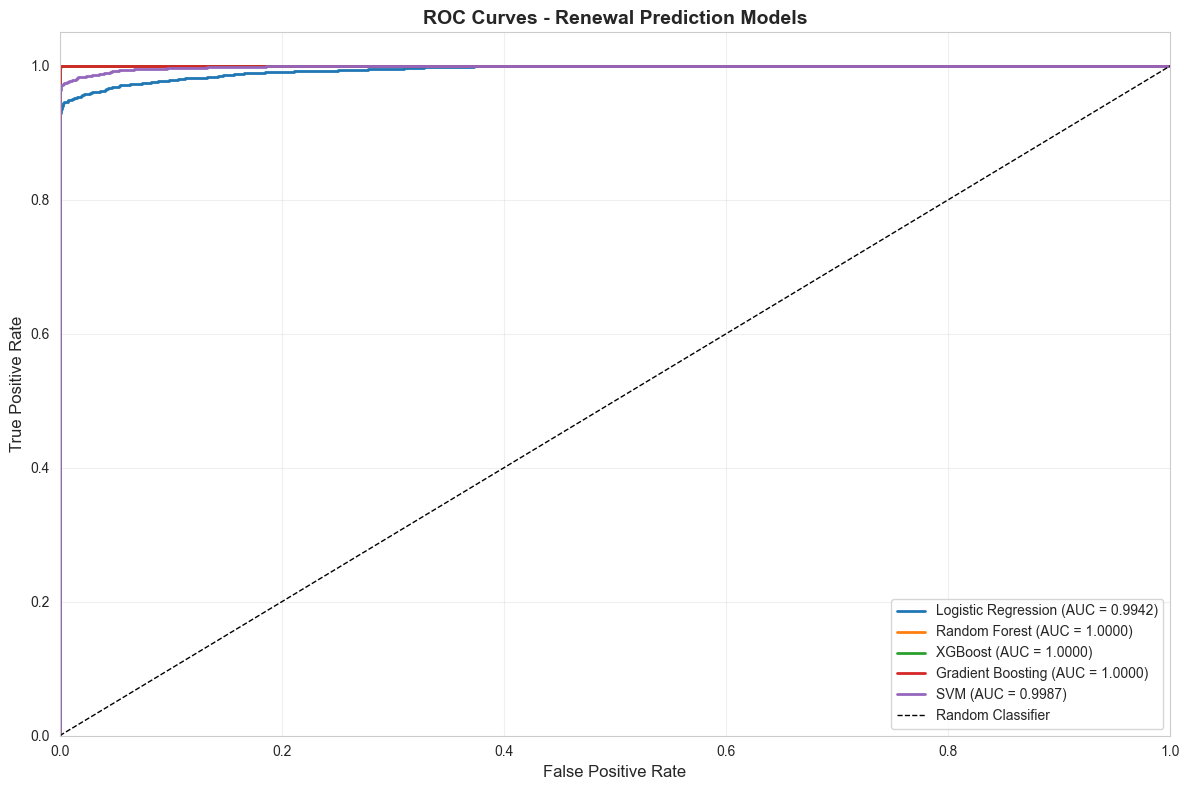

In [13]:
# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results[name]["ROC-AUC"]:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Renewal Prediction Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Ensemble Models

In [14]:
# Create ensemble models using the trained base models
print("=" * 80)
print("TRAINING ENSEMBLE MODELS")
print("=" * 80)

# Use tuned/trained models from the models dictionary
base_models_for_ensemble = []

# Get tree-based models for ensemble (exclude SVM and Logistic Regression for faster training)
tree_model_names = ['Random Forest', 'XGBoost', 'Gradient Boosting']
for name in tree_model_names:
    if name in models:
        # Create a copy to avoid modifying the original
        base_models_for_ensemble.append((name.lower().replace(' ', '_'), models[name]))

if len(base_models_for_ensemble) < 2:
    print("⚠️  Warning: Need at least 2 models for ensemble. Adding all available models...")
    for name, model in models.items():
        if name not in ['SVM']:  # Exclude SVM for ensemble
            base_models_for_ensemble.append((name.lower().replace(' ', '_'), model))

print(f"\nBase models for ensemble: {[name for name, _ in base_models_for_ensemble]}")

# Create Voting Classifier (Soft Voting - uses probabilities)
print("\nTraining Voting Classifier (Soft Voting)...")
voting_clf = VotingClassifier(
    estimators=base_models_for_ensemble,
    voting='soft',  # Use soft voting for probability-based predictions
    n_jobs=-1
)
voting_clf.fit(X_train, y_train)

# Evaluate Voting Classifier
voting_pred = voting_clf.predict(X_test)
voting_proba = voting_clf.predict_proba(X_test)[:, 1]

voting_accuracy = accuracy_score(y_test, voting_pred)
voting_precision = precision_score(y_test, voting_pred)
voting_recall = recall_score(y_test, voting_pred)
voting_f1 = f1_score(y_test, voting_pred)
voting_roc_auc = roc_auc_score(y_test, voting_proba)

results['Voting Classifier'] = {
    'Accuracy': voting_accuracy,
    'Precision': voting_precision,
    'Recall': voting_recall,
    'F1-Score': voting_f1,
    'ROC-AUC': voting_roc_auc
}
predictions['Voting Classifier'] = voting_pred
probabilities['Voting Classifier'] = voting_proba

print(f"  Accuracy: {voting_accuracy:.4f}")
print(f"  Precision: {voting_precision:.4f}")
print(f"  Recall: {voting_recall:.4f}")
print(f"  F1-Score: {voting_f1:.4f}")
print(f"  ROC-AUC: {voting_roc_auc:.4f}")

# Create Stacking Classifier (uses meta-learner)
print("\nTraining Stacking Classifier...")
stacking_clf = StackingClassifier(
    estimators=base_models_for_ensemble,
    final_estimator=LogisticRegression(random_state=42, max_iter=1000),
    cv=5,
    n_jobs=-1
)
stacking_clf.fit(X_train, y_train)

# Evaluate Stacking Classifier
stacking_pred = stacking_clf.predict(X_test)
stacking_proba = stacking_clf.predict_proba(X_test)[:, 1]

stacking_accuracy = accuracy_score(y_test, stacking_pred)
stacking_precision = precision_score(y_test, stacking_pred)
stacking_recall = recall_score(y_test, stacking_pred)
stacking_f1 = f1_score(y_test, stacking_pred)
stacking_roc_auc = roc_auc_score(y_test, stacking_proba)

results['Stacking Classifier'] = {
    'Accuracy': stacking_accuracy,
    'Precision': stacking_precision,
    'Recall': stacking_recall,
    'F1-Score': stacking_f1,
    'ROC-AUC': stacking_roc_auc
}
predictions['Stacking Classifier'] = stacking_pred
probabilities['Stacking Classifier'] = stacking_proba

print(f"  Accuracy: {stacking_accuracy:.4f}")
print(f"  Precision: {stacking_precision:.4f}")
print(f"  Recall: {stacking_recall:.4f}")
print(f"  F1-Score: {stacking_f1:.4f}")
print(f"  ROC-AUC: {stacking_roc_auc:.4f}")

# Add ensemble models to models dictionary for saving
models['Voting Classifier'] = voting_clf
models['Stacking Classifier'] = stacking_clf

print("\n" + "=" * 80)
print("Ensemble models trained successfully!")
print("=" * 80)

TRAINING ENSEMBLE MODELS

Base models for ensemble: ['random_forest', 'xgboost', 'gradient_boosting']

Training Voting Classifier (Soft Voting)...
  Accuracy: 0.9998
  Precision: 0.9998
  Recall: 1.0000
  F1-Score: 0.9999
  ROC-AUC: 1.0000

Training Stacking Classifier...
  Accuracy: 0.9998
  Precision: 0.9998
  Recall: 1.0000
  F1-Score: 0.9999
  ROC-AUC: 1.0000

Ensemble models trained successfully!


## 11. Feature Importance Analysis

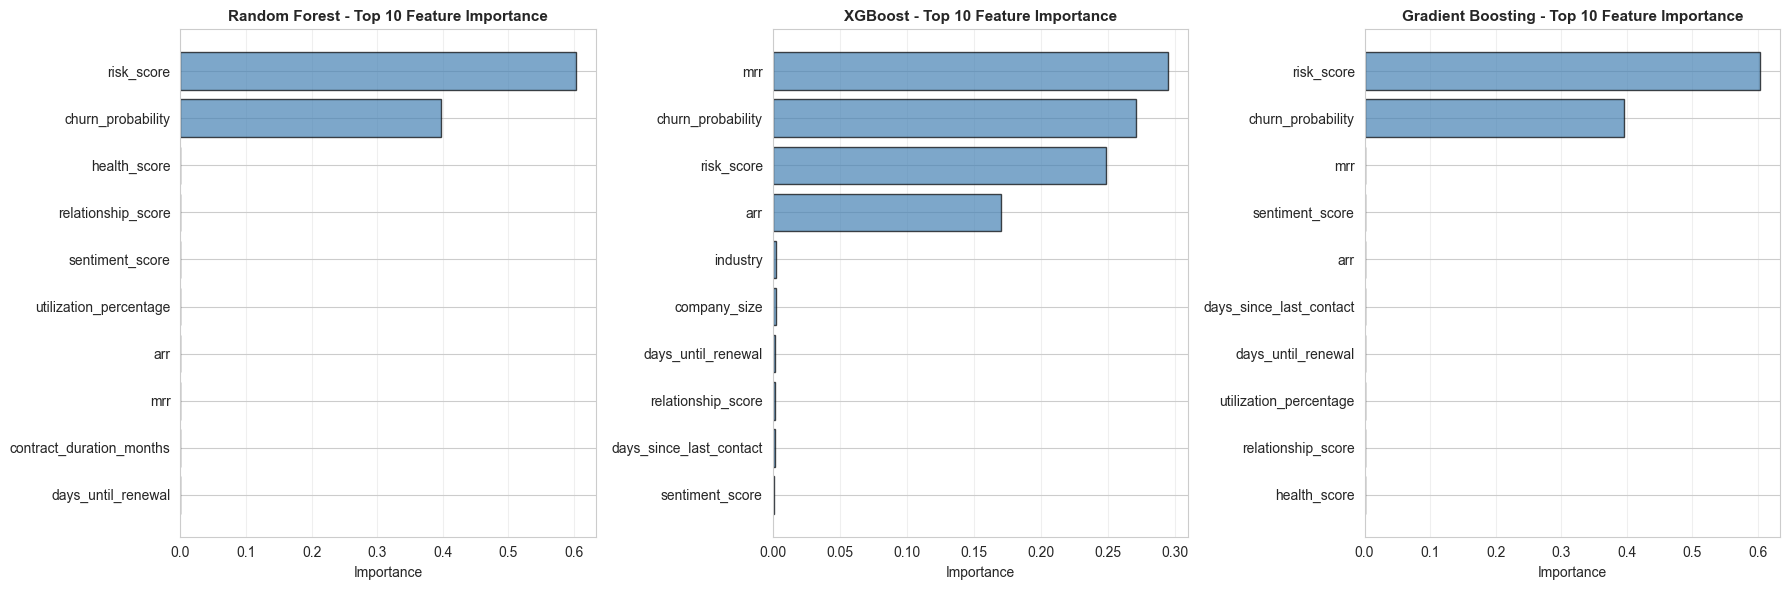

FEATURE IMPORTANCE ANALYSIS

Random Forest - Feature Importance:
------------------------------------------------------------
                 Feature  Importance
              risk_score    0.603427
       churn_probability    0.396573
            health_score    0.000000
      relationship_score    0.000000
         sentiment_score    0.000000
  utilization_percentage    0.000000
                     arr    0.000000
                     mrr    0.000000
contract_duration_months    0.000000
      days_until_renewal    0.000000
 days_since_last_contact    0.000000
                industry    0.000000
            company_size    0.000000


XGBoost - Feature Importance:
------------------------------------------------------------
                 Feature  Importance
                     mrr    0.295129
       churn_probability    0.271430
              risk_score    0.248666
                     arr    0.170346
                industry    0.002643
            company_size    0.002285
    

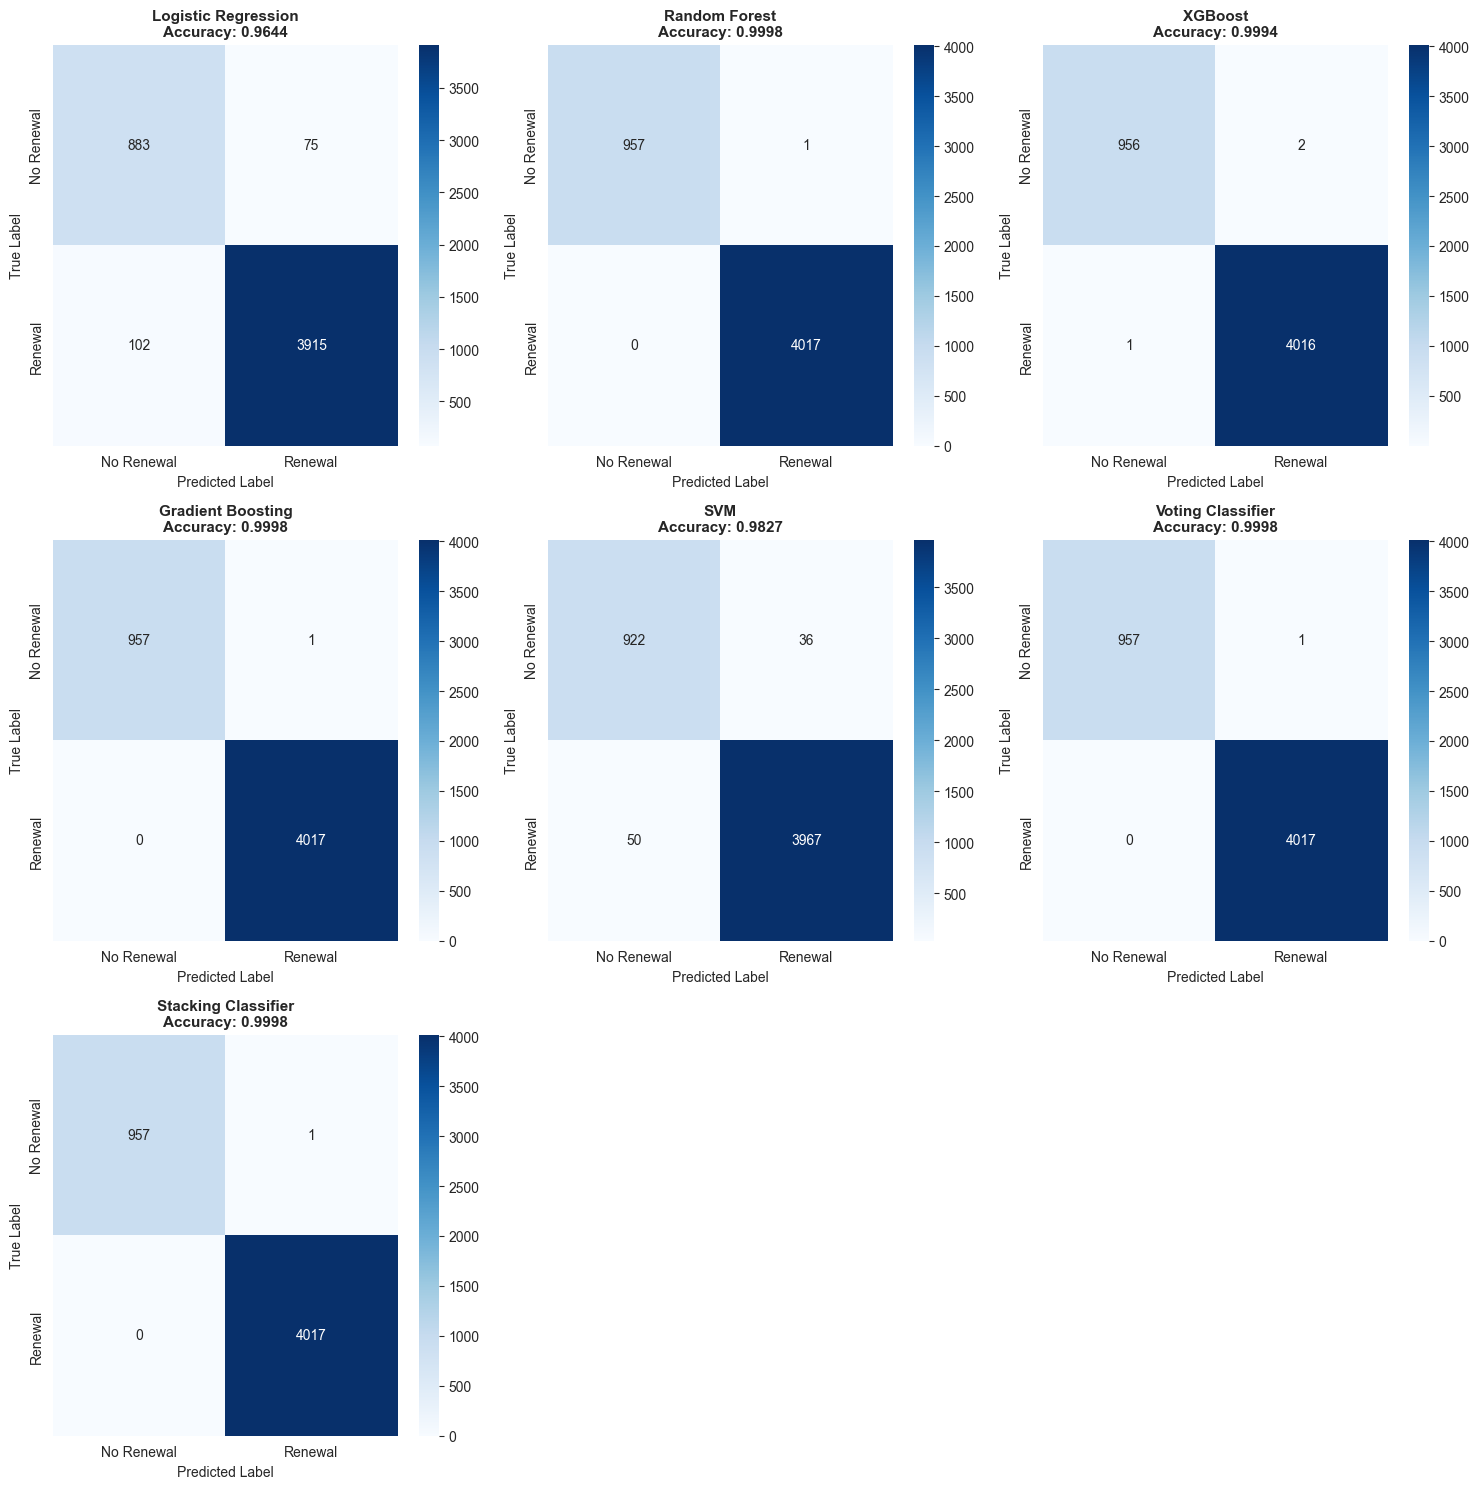

CLASSIFICATION REPORTS

Logistic Regression:
------------------------------------------------------------
              precision    recall  f1-score   support

  No Renewal       0.90      0.92      0.91       958
     Renewal       0.98      0.97      0.98      4017

    accuracy                           0.96      4975
   macro avg       0.94      0.95      0.94      4975
weighted avg       0.96      0.96      0.96      4975


Random Forest:
------------------------------------------------------------
              precision    recall  f1-score   support

  No Renewal       1.00      1.00      1.00       958
     Renewal       1.00      1.00      1.00      4017

    accuracy                           1.00      4975
   macro avg       1.00      1.00      1.00      4975
weighted avg       1.00      1.00      1.00      4975


XGBoost:
------------------------------------------------------------
              precision    recall  f1-score   support

  No Renewal       1.00      1.00    

SAVING MODELS
✓ Saved Logistic Regression: renewal_model_logistic_regression_20260214_214502.pkl
✓ Saved Random Forest: renewal_model_random_forest_20260214_214502.pkl
✓ Saved XGBoost: renewal_model_xgboost_20260214_214502.pkl
✓ Saved Gradient Boosting: renewal_model_gradient_boosting_20260214_214502.pkl
✓ Saved SVM: renewal_model_svm_20260214_214502.pkl
✓ Saved Voting Classifier: renewal_model_voting_classifier_20260214_214502.pkl
✓ Saved Stacking Classifier: renewal_model_stacking_classifier_20260214_214502.pkl
✓ Saved preprocessing objects: renewal_preprocessing_20260214_214502.pkl
✓ Saved BEST MODEL (Random Forest): renewal_model_best_20260214_214502.pkl
✓ Saved model results: renewal_model_results_20260214_214502.csv
✓ Saved detailed results: renewal_model_results_20260214_214502.pkl

MODEL SAVING SUMMARY
Total models saved: 7
Best model: Random Forest (Overall Score: 0.9999)
Models directory: d:\Internship\Renewal-Upsell-Advisor\Research\renewal\models
Timestamp: 20260214_214502


MODEL LOADING EXAMPLE

To load the best model:
```python
import joblib
from pathlib import Path

# Load best model
best_model = joblib.load('models\renewal_model_best_20260214_214502.pkl')

# Load preprocessing objects
preprocessing = joblib.load('models\renewal_preprocessing_20260214_214502.pkl')
scaler = preprocessing['scaler']
label_encoders = preprocessing['label_encoders']

# Make predictions on new data
# (Remember to preprocess new data the same way)
predictions = best_model.predict_proba(new_data)[:, 1]
```

To load a specific model:
```python
# Example: Load Random Forest model
rf_model = joblib.load('models/renewal_model_random_forest_20260214_214502.pkl')
```

To load all results:
```python
import pickle

with open('models\renewal_model_results_20260214_214502.pkl', 'rb') as f:
    all_results = pickle.load(f)
    
results = all_results['results']
best_model_name = all_results['best_model_name']
```


In [19]:
# Final summary of all models
print("=" * 80)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 80)

final_results_df = pd.DataFrame(results).T
final_results_df = final_results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].sort_values('ROC-AUC', ascending=False)

print("\nAll Models Performance (sorted by ROC-AUC):")
print(final_results_df.round(4))

print(f"\n{'='*80}")
print("BEST MODEL SELECTION")
print(f"{'='*80}")
print(f"Best Model: {best_model_name}")
print(f"  Accuracy: {final_results_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"  Precision: {final_results_df.loc[best_model_name, 'Precision']:.4f}")
print(f"  Recall: {final_results_df.loc[best_model_name, 'Recall']:.4f}")
print(f"  F1-Score: {final_results_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"  ROC-AUC: {final_results_df.loc[best_model_name, 'ROC-AUC']:.4f}")

print(f"\n{'='*80}")
print("MODEL TRAINING PIPELINE COMPLETE!")
print(f"{'='*80}")
print(f"✓ {len(models)} models trained")
print(f"✓ Hyperparameter tuning: {'Enabled' if ENABLE_TUNING else 'Disabled'}")
print(f"✓ Ensemble models: Voting Classifier, Stacking Classifier")
print(f"✓ All models saved to: {models_dir.absolute()}")
print(f"✓ Best model: {best_model_name}")
print(f"✓ Ready for production use!")
print(f"{'='*80}")

FINAL MODEL PERFORMANCE SUMMARY

All Models Performance (sorted by ROC-AUC):
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest          0.9998     0.9998  1.0000    0.9999   1.0000
Voting Classifier      0.9998     0.9998  1.0000    0.9999   1.0000
Gradient Boosting      0.9998     0.9998  1.0000    0.9999   1.0000
Stacking Classifier    0.9998     0.9998  1.0000    0.9999   1.0000
XGBoost                0.9994     0.9995  0.9998    0.9996   1.0000
SVM                    0.9827     0.9910  0.9876    0.9893   0.9987
Logistic Regression    0.9644     0.9812  0.9746    0.9779   0.9942

BEST MODEL SELECTION
Best Model: Random Forest
  Accuracy: 0.9998
  Precision: 0.9998
  Recall: 1.0000
  F1-Score: 0.9999
  ROC-AUC: 1.0000

MODEL TRAINING PIPELINE COMPLETE!
✓ 7 models trained
✓ Hyperparameter tuning: Enabled
✓ Ensemble models: Voting Classifier, Stacking Classifier
✓ All models saved to: d:\Internship\Renewal-Upsell-Advisor\Research\renewal\models
✓ Best mo